 **ANALISIS DATA PENJUALAN SEPEDA MOTOR BEKAS**

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [47]:
file = "/content/drive/MyDrive/AVD/BIKE DETAILS.csv"
df = pd.read_csv(file)

df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


# **Business Understanding**

## **Business Objective**


Dataset ini berisi tentang penjualan sepeda motor bekas pakai, terdapat informasi seperti nama jenis motor, harga jual, tahun dibeli, status kepemilikan, kilometer yang sudah ditempuh dan harga penjualan di *showroom* awal beli. Tujuan dilakukannya analisis dari data tersbut ialah untuk mengetahui tren harga jual motor bekas dengan melihat informasi dari kilometer dan tahun pembelian. Selain dari itu, pembeli dapat membandingkan harga sekarang dengan harga dari *showroom* sebelumnya.

## **Assess Situation**


Dataset ini memiliki banyak tantangan, mulai dari banyaknya data yang kurang di bagian *ex_showroom_price* yang menyebabkan sulitnya dilakukan perbandingan harga, selain itu terdapat juga penduplikasian data yang terjadi hingga terdapatnya informasi tentang rentang tahun yang sangat jauh menyebabkan tren harga ikut berubah jauh. Selain hal hal tersebut terdapat juga ketidak konsistenan penulisan di bagian *km_driven* yang kurang masuk akal.

## **Analytic Goals & Project Plan**


Analisis yang dilakukan untuk mengatasi tantangan tangtangan diatas adalah dengan:

*   Menganalisis hubungan antara harga jual dan tahun produksi dengan tujuan untuk mengetahui apakah motor yang keluaran terberu akan lebih mahal atau tidak
*   Melakukan perbandingan harga jual dengan harga penjual dari *showroom*
*   Mengidentifikasi data yang memiliki kekurangan informasi dan terdapat duplikasi agar analisis menjadi lebih akurat
*   Segmentasi berdasarkan merek atau model motor populer



Rencana yang sudah disiapkan berupa:

*   Memahami data dengan mengecek struktur dataset dan mengidentifikasi hilangnya informasi dan duplikasi yang terjadi
*   Mengolah data dengan menghapus data yang terduplikasi dan memperbaiki kesalahan pada penulisan di kilometer jarak tempuh agar konsisten
*   Melakukan eksplorasi data lebih mendalam dan juga analisis segmentasi untuk motor yang bermerek dan bermodel populer yang sedang tren saat ini
*   Membuat *insight* atau kesimpulan dengan menyimpulkan faktor faktor yang memengaruhi harga jual motor bekas dan memberikan rekomendasi kepada pembeli untuk tau kapan waktu yang tepat dalam membeli motor bekas.

## **Struktu Data**

### **Informasi Dasar**

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 1061 Baris dan 7 Kolom, selain itu terdapat juga 1 tipe data float, 3 tipe data integer, dan 3 tipe data object.

### **Informasi Lanjutan**

1. name: 0
        Jumlah baris: 1061
        Tipe data: object
        Deskripsi: Kolom nama motor, mencakup merek dan model

2. Selling Price: 1
        Jumlah baris: 1061
        Tipe data: int64
        Deskripsi: Harga penjualan motor bekas

3. Year: 2
        Jumlah baris: 1061
        Tipe data: int64
        Deskripsi: Tahun motornya dibeli oleh pemilik sebelumnya

4. Seller Type: 3
        Jumlah baris: 1061
        Tipe data: object
        Deskripsi: tipe penjual (dealer atau individual)

5. Owner: 4
        Jumlah baris: 1061
        Tipe data: object
        Deskripsi: Status kepemilikan motor (pemilik pertama, kedua dan seterusnya)

6. Km Driven: 5
        Jumlah baris: 1061
        Tipe data: int64
        Deskripsi: Jarak tempuh motor

7. Market: 6
        Jumlah baris: 626
        Tipe data: float64
        Deskripsi: Harga motor pada showroom saat pertama kali dibeli

In [49]:
df.describe(include='all')

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
count,1061,1061.000000,1061.000000,1061,1061,1061.000000,6.260000e+02
unique,279,NaN,NaN,2,4,NaN,NaN
top,Bajaj Pulsar 150,NaN,NaN,Individual,1st owner,NaN,NaN
freq,41,NaN,NaN,1055,924,NaN,NaN
mean,NaN,59638.151744,2013.867107,NaN,NaN,34359.833176,8.795871e+04
std,NaN,56304.291973,4.301191,NaN,NaN,51623.152702,7.749659e+04
min,NaN,5000.000000,1988.000000,NaN,NaN,350.000000,3.049000e+04
25%,NaN,28000.000000,2011.000000,NaN,NaN,13500.000000,5.485200e+04
50%,NaN,45000.000000,2015.000000,NaN,NaN,25000.000000,7.275250e+04
75%,NaN,70000.000000,2017.000000,NaN,NaN,43000.000000,8.703150e+04


1. Count (Kelengkapan Data)
Berdasarkan data, total baris dalam dataset motor bekas adalah 1061 dengan data yang hilang:
* ex_showroom_price memiliki 435 data yang hilang (tersisa 626 data)

Kesimpulan: Hampir semua kolom lengkap kecuali kolom ex_showroom_price yang perlu diperbaiki.



---



2. Mean vs Median (Distribusi Data)

* selling_price
  * Mean = 59.638
  * Median = 45.000

Rata-rata lebih tinggi dari median → ada motor dengan harga sangat mahal (contoh Harley-Davidson, BMW, Kawasaki) yang membuat rata-rata naik.

* year
  * Mean = 2013,87
  * Median = 2015

Median lebih tinggi dari mean → mayoritas motor relatif baru (sekitar 2015–2017), tetapi ada data motor lama (1988–2000) yang menurunkan rata-rata.

* km_driven
  * Mean = 34.359
  * Median = 25.000

Rata-rata lebih tinggi dari median → ada motor dengan jarak tempuh ekstrem (hingga 880.000 km) yang menarik rata-rata ke atas.

* ex_showroom_price
  * Mean = 87.958
  * Median = 72.752

Rata-rata lebih tinggi dari median → motor premium dengan harga showroom sangat tinggi membuat distribusi condong ke kanan.

Kesimpulan: Distribusi data numerik cenderung right-skewed (condong ke kanan), dipengaruhi oleh outlier motor premium dan jarak tempuh ekstrem.




---



3. Min dan Max (Validasi Logika)

* selling_price
  * Min = 5.000
  * Max = 760.000
  * Rentang harga wajar, dari motor murah hingga motor premium.

* year
  * Min = 1988
  * Max = 2020
  * Rentang masuk akal, mencakup motor klasik hingga motor baru.

* km_driven
  * Min = 350 km
  * Max = 880.000 km
  * Nilai maksimum sangat tinggi, perlu validasi apakah benar atau kesalahan input.

* ex_showroom_price
  * Min = 34.900
  * Max = 1.278.000
  * Rentang harga showroom wajar, dari motor entry-level hingga motor premium.

Kesimpulan: Ada beberapa nilai ekstrem (km_driven 880.000 km) yang perlu dicek ulang.




---



4. Standar Deviasi (std) - Variabilitas Data

* selling_price
  * Mean = 59.638
  * Std = 56.304
  * Variasi harga sangat tinggi, hampir setara dengan rata-rata.

* year
  * Mean = 2013,87
  * Std = 4,30
  * Variasi tahun produksi relatif kecil, mayoritas motor dalam rentang 2010–2020.

* km_driven
  * Mean = 34.359
  * Std = 51.623
  * Variasi jarak tempuh sangat besar, dari motor baru hingga motor dengan penggunaan ekstrem.

* ex_showroom_price
  * Mean = 87.958
  * Std = 77.495
  * Variasi harga showroom tinggi, menunjukkan perbedaan besar antara motor entry-level dan premium.


Kesimpulan:

* Variabilitas tinggi pada selling_price, km_driven, dan ex_showroom_price menunjukkan dataset mencakup motor dengan kondisi dan segmen pasar yang sangat beragam.

## **Verifikasi Kualitas Data**

### **Cek Data Setiap Kolom**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

Dan dapat dilihat dibawah ini, kolom selling price dengan tipe data integer, seharusnya kolom ini bertipe data kan float. Selain itu, semua kolom sudah sesuai.

In [50]:
df.dtypes

,0
name,object
selling_price,int64
year,int64
seller_type,object
owner,object
km_driven,int64
ex_showroom_price,float64


### **Incosistent Values**

Pada tahap ini, saya melakukan mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

In [51]:
print(df['year'].unique())

[2019 2017 2018 2015 2011 2010 2008 2016 2020 2012 2006 2013 2009 2014
 2004 2007 2000 2002 2005 1997 2001 1988 1999 1998 1991 2003 1993 1995]


Ada motor dengan tahun produksi sangat lama (1988, 1997, 2000) bercampur dengan motor baru (2019–2020). Secara logis masih mungkin, tapi perlu validasi apakah data lama memang relevan.

In [52]:
print(df['name'].unique())

['Royal Enfield Classic 350' 'Honda Dio'
 'Royal Enfield Classic Gunmetal Grey' 'Yamaha Fazer FI V 2.0 [2016-2018]'
 'Yamaha SZ [2013-2014]' 'Honda CB Twister' 'Honda CB Hornet 160R'
 'Royal Enfield Bullet 350 [2007-2011]' 'Hero Honda CBZ extreme'
 'Bajaj Discover 125' 'Yamaha FZ16' 'Honda Navi'
 'Bajaj Avenger Street 220' 'Yamaha YZF R3' 'Jawa 42'
 'Suzuki Access 125 [2007-2016]' 'Hero Honda Glamour' 'Yamaha YZF R15 S'
 'Yamaha FZ25' 'Hero Passion Pro 110' 'Honda Navi [2016-2017]'
 'Honda Activa i' 'Jawa Standard' 'Royal Enfield Thunderbird 350'
 'Honda Dream Yuga' 'TVS Apache RTR 160 4V' 'Yamaha Fazer [2009-2016]'
 'Hero Honda Splendor NXG' 'Hero Glamour 125' 'Yamaha FZ S [2012-2016]'
 'Hero Xtreme Sports' 'Honda X-Blade' 'Honda CB Shine SP'
 'Honda Activa 5G' 'Honda CBR-250R' 'Hero Honda Passion PRO [2012]'
 'Bajaj Dominar 400' 'Hero Glamour FI' 'KTM 390 Duke' 'Hero Passion XPro'
 'Yamaha FZ S V 2.0' 'Hero Achiever 150' 'Yamaha Saluto'
 'Bajaj Discover 100' 'Honda CB Trigger' 'Royal

Ada nilai ekstrem seperti 500.000 km dan 880.000 km, yang tidak realistis untuk motor. Bisa jadi kesalahan input.


Untuk data pada kolom sisanya tidak terdapat ketidak konsistenan. Karena dataset yang dimasukan tidak mengandung kesalahan penulisan kata maupun huruf.

### **Missing Velues**

In [53]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
name,0.000000
selling_price,0.000000
year,0.000000
seller_type,0.000000
owner,0.000000
km_driven,0.000000
ex_showroom_price,40.999057


Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom. Dan terlihat bahwa kolom:
* Ex Showroom Price

Memiliki missing values sekitar 40%, sesuai dengan informasi data yang sudah ditulis yaitu sekitar 435 data hilang dalam bagian tersebut. Maka akan dilakukan analisis lebih lanjut dan untuk memperbaiki data yang hilang.

### **Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [54]:
df[df.duplicated()]

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
231,TVS Apache RTR 200 4V,95000,2018,Individual,1st owner,9600,NaN
508,Bajaj Pulsar 135 LS,20000,2010,Individual,1st owner,80000,64589.0
522,Bajaj Platina 100,20000,2012,Individual,1st owner,16295,NaN
605,Hero Karizma [2003-2014],50000,2013,Individual,1st owner,38000,85766.0
607,Honda CB Hornet 160R,70000,2017,Individual,1st owner,35000,87719.0
773,Honda Activa [2000-2015],23000,2009,Individual,1st owner,95000,50267.0


Bagian hasil menunjukkan adanya baris duplikat dalam dataset. Contoh yang muncul adalah TVS Apache RTR 200 4V, Bajaj Pulsar 135 LS, Bajaj Platina 100, Hero Karizma [2003-2014], Honda CB Hornet 160R, dan Honda Activa [2000-2015].  

Hal tersebut bisa terjadi karena data ganda yang masuk lebih dari sekali, kesalahan input, atau memang ada motor berbeda dengan spesifikasi identik sehingga terlihat sama.  

Langkah yang disarankan adalah melakukan pembersihan data dengan menghapus duplikat menggunakan fungsi seperti df = drop_duplicates(), atau memverifikasi terlebih dahulu apakah duplikat tersebut merupakan benar-benar motor yang sama atau hanya kebetulan identik.


### **Outliers Velues**

In [55]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
selling_price,8.199811
year,1.696513
km_driven,3.675778
ex_showroom_price,6.880302


Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.

Akan tetapi memang tidak semua kolom perlu kita tangani, kita harus tetap melihat dan memahami tujuan dari setiap kolom yang ada di dataset.

Dan terlihat kolom
* selling_price (8,19%) → Persentase outlier cukup tinggi. Ini menunjukkan ada banyak motor dengan harga jauh di luar pola umum, baik sangat murah maupun sangat mahal. Hal ini bisa memengaruhi analisis harga rata-rata.

* year (1,69%) → Outlier relatif kecil. Artinya hanya sedikit motor dengan tahun produksi yang sangat tua atau sangat baru dibanding mayoritas data.

* km_driven (3,67%) → Ada sejumlah motor dengan jarak tempuh ekstrem. Persentase ini cukup signifikan karena bisa memengaruhi distribusi kondisi kendaraan.

* ex_showroom_price (6,88%) → Outlier cukup tinggi. Ini menandakan adanya motor premium dengan harga showroom jauh lebih tinggi dibanding mayoritas motor lain.


Kesimpulan: Outlier paling dominan ada di selling_price dan ex_showroom_price, yang menunjukkan variasi besar antara motor entry-level dan motor premium. Outlier di km_driven juga penting karena bisa menandakan data input ekstrem. Sedangkan outlier di year relatif kecil sehingga tidak terlalu mengganggu distribusi.

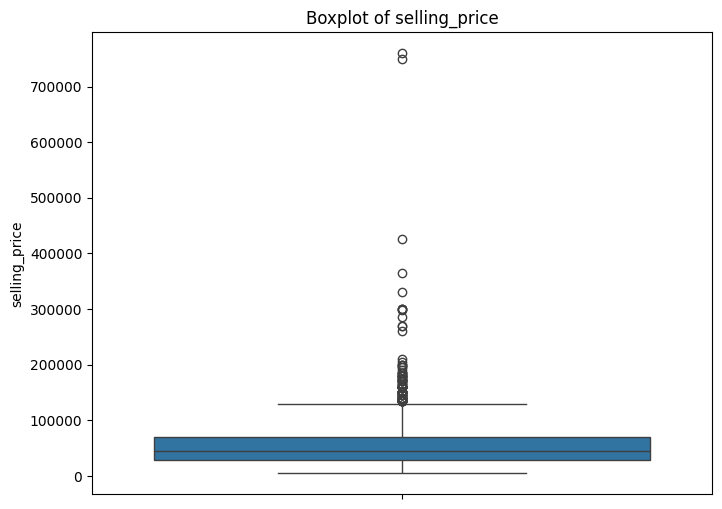

In [56]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['selling_price'])
plt.title('Boxplot of selling_price')
plt.ylabel('selling_price')
plt.show()

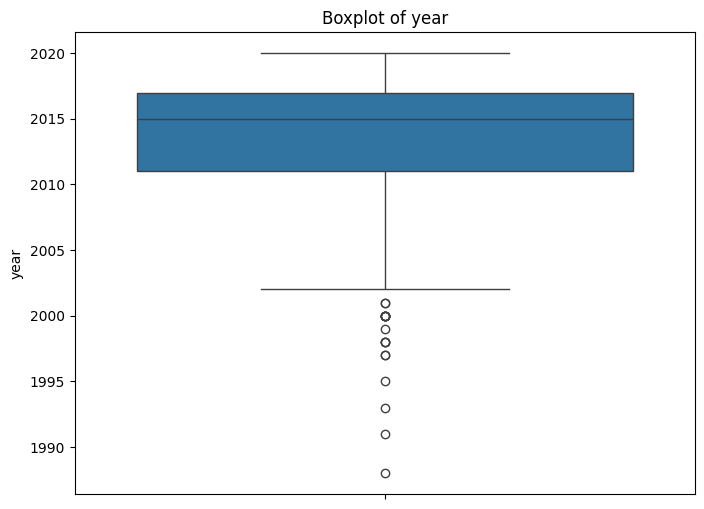

In [57]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['year'])
plt.title('Boxplot of year')
plt.ylabel('year')
plt.show()

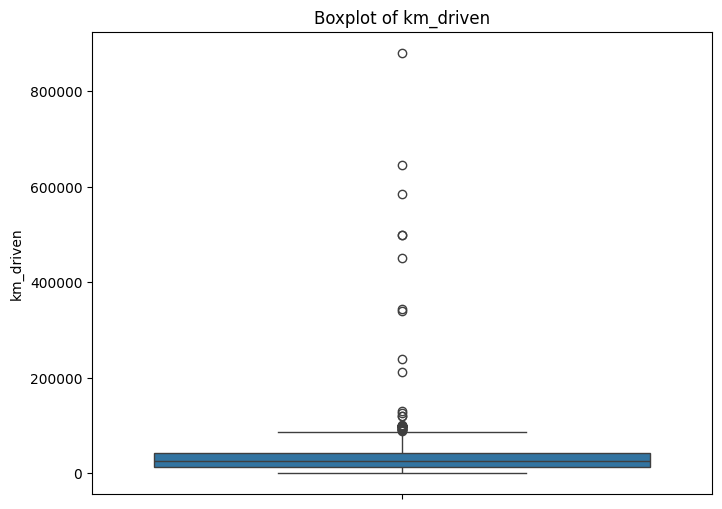

In [58]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['km_driven'])
plt.title('Boxplot of km_driven')
plt.ylabel('km_driven')
plt.show()

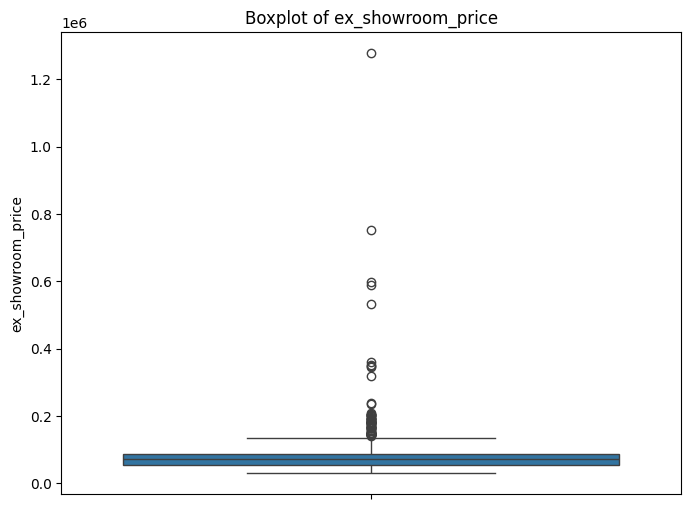

In [59]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['ex_showroom_price'])
plt.title('Boxplot of ex_showroom_price')
plt.ylabel('ex_showroom_price')
plt.show()

# **Eksplorasi Data (EDA)**

## **Comparison(Perbandingan)**

Aktivitas: Membandingkan pemilik (owner) dengan harga jual (selling_price).

Tujuan: Mengetahui penjelasan karena Motor dengan owner pertama umumnya memiliki harga lebih tinggi dibanding motor dengan kepemilikan kedua atau ketiga.


Visualisasi: Bar Chart (Grafik Batang).

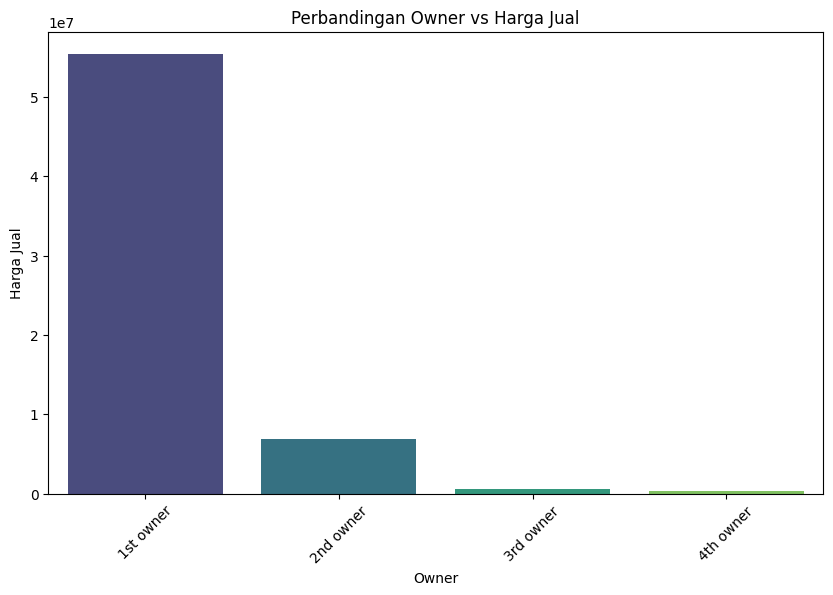

In [60]:
harga = df.groupby('owner')['selling_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=harga.index, y=harga.values, palette='viridis', hue=harga.index, legend=False)
plt.title('Perbandingan Owner vs Harga Jual')
plt.xlabel('Owner')
plt.ylabel('Harga Jual')
plt.xticks(rotation=45)
plt.show()

Grafik batang yang ditampilkan memperlihatkan perbandingan total harga jual motor berdasarkan status kepemilikan.

Motor dengan 1st owner memiliki total harga jual yang jauh lebih tinggi dibandingkan kategori lainnya. Hal ini menunjukkan bahwa motor yang masih dimiliki oleh pemilik pertama cenderung lebih bernilai dan lebih diminati di pasar.

Sementara itu, motor dengan 2nd owner, 3rd owner, dan 4th owner memiliki total harga jual yang lebih rendah. Pola ini menegaskan bahwa semakin banyak pergantian kepemilikan, nilai jual motor cenderung menurun.

Sehingga riwayat kepemilikan berpengaruh signifikan terhadap harga jual, dengan kepemilikan pertama menjadi faktor yang paling kuat dalam menjaga nilai kendaraan.


## **Composition(Komposisi)**

Aktivitas: Melihat proporsi atau persentase pemilik yang sudah memakai motor bekas (owner).

Tujuan: Mengetahui dan memahami pengaruh riwayat kepemilikan terhadap nilai jual motor

Visualisasi: Pie Chart (Grafik Lingkaran).

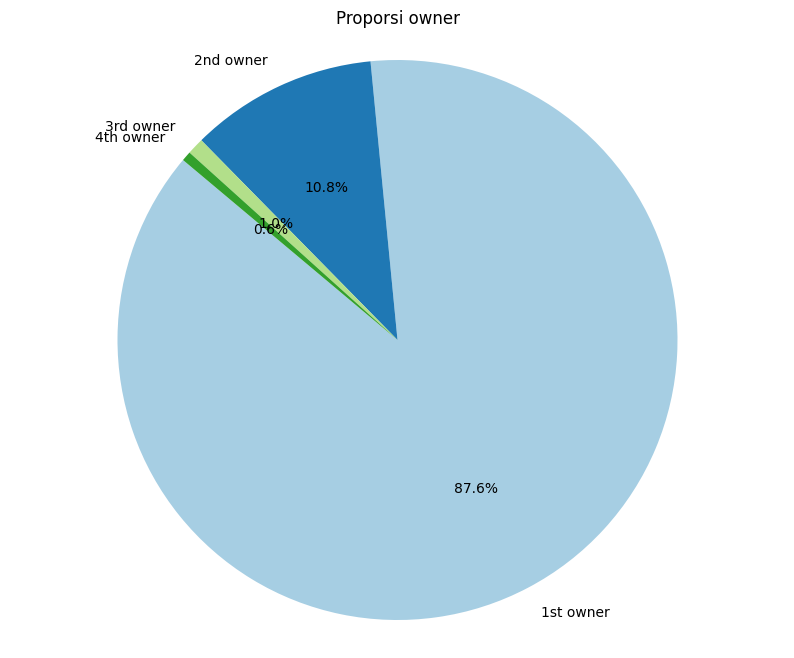

In [61]:
owner = df.groupby('owner')['selling_price'].sum().sort_values(ascending=False)
owner = owner.head(4)

plt.figure(figsize=(10, 8))
owner.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi owner')
plt.ylabel('')
plt.axis('equal')
plt.show()

Menunjukkan bahwa mayoritas motor dalam dataset berasal dari 1st owner dengan persentase sekitar 87,6%. Hal ini menegaskan bahwa sebagian besar motor yang dijual masih dimiliki oleh pemilik pertama.

Kategori 2nd owner menempati posisi kedua dengan 10,8%, sementara 3rd owner dan 4th owner hanya menyumbang kurang dari 2% secara keseluruhan.

Riwayat kepemilikan sangat memengaruhi nilai jual motor. Motor dengan kepemilikan pertama lebih dominan di pasar dan cenderung memiliki harga jual lebih tinggi, sedangkan motor dengan kepemilikan lebih dari satu relatif jarang dan nilainya lebih rendah.

## **Distribution(Distribusi)**

>



Aktivitas: Menganalisis penyebaran nilai harga showroom motor pada kolom (ex_showroom_price).

Tujuan: Mengetahui apakah mayoritas motor berada di kisaran harga rendah-menengah atau tinggi, serta mendeteksi adanya kecondongan (skewness) akibat motor premium.

Visualisasi: Histogram.

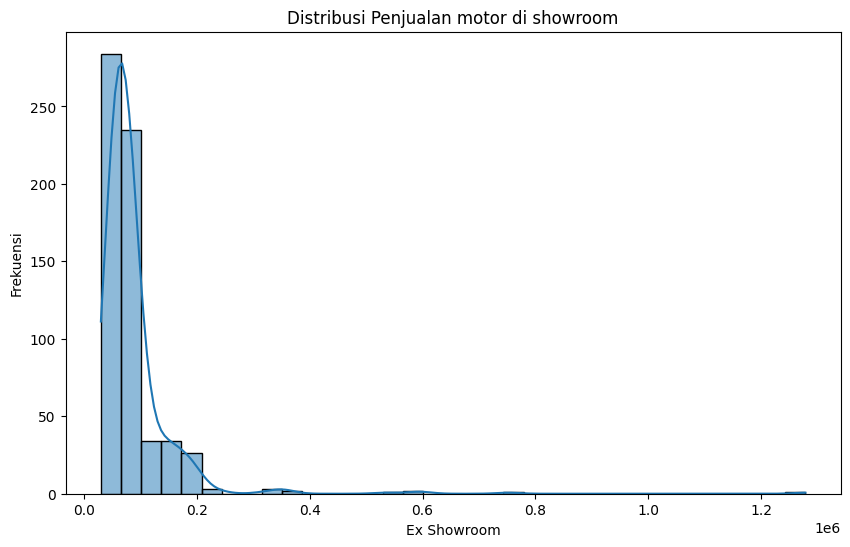

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ex_showroom_price'], bins=35, kde=True)
plt.title('Distribusi Penjualan motor di showroom')
plt.xlabel('Ex Showroom')
plt.ylabel('Frekuensi')
plt.show()

Distribusi ex_showroom_price menunjukkan bahwa mayoritas motor berada di kisaran harga rendah hingga menengah, dengan konsentrasi data di bawah 100.000. Garis KDE memperlihatkan puncak distribusi yang jelas di area tersebut.

Namun, distribusi terlihat right-skewed (condong ke kanan). Hal ini terjadi karena adanya motor premium dengan harga showroom jauh lebih tinggi, yang mendorong nilai maksimum hingga lebih dari 1.200.000.

Pasar motor didominasi oleh segmen entry-level dan menengah, sementara motor premium hanya sedikit tetapi cukup memengaruhi bentuk distribusi secara keseluruhan. Ini penting untuk analisis harga karena outlier dari motor premium dapat menggeser rata-rata dan membuat distribusi terlihat tidak seimbang.


## **Relationship(Hubungan)**

Aktivitas: Menganalisis hubungan antara harga jual motor bekas (selling_price) dengan harga showroom (ex_showroom_price).

Tujuan: Melihat apakah motor dengan harga showroom tinggi tetap memiliki harga jual tinggi meskipun sudah bekas.

Visualisasi: Heatmap

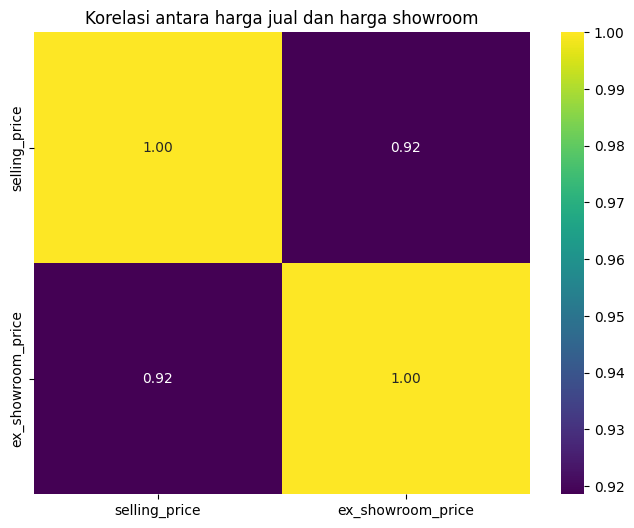

In [63]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['selling_price', 'ex_showroom_price']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara harga jual dan harga showroom')
plt.show()

Heatmap korelasi antara selling_price dan ex_showroom_price menunjukkan adanya hubungan yang sangat kuat dengan nilai korelasi sebesar (0,92).

Hal ini berarti motor dengan harga showroom tinggi cenderung tetap memiliki harga jual tinggi meskipun sudah bekas. Korelasi yang kuat ini menegaskan bahwa harga showroom merupakan salah satu faktor utama yang memengaruhi nilai jual motor di pasar second-hand.

Harga showroom dapat dijadikan indikator penting dalam memprediksi harga jual motor bekas. Motor premium dengan showroom price tinggi akan tetap mempertahankan nilai jual lebih baik dibanding motor entry-level, meskipun terjadi depresiasi karena penggunaan.

# **Data Preparation**

Setelah Mengecek semua kesealahan pada dataset, selanjutnya akan dilakukan perbaikan data.

### **Perbaikan Tipe Data**

Pada bagian ini tipe data saya sesuai pada penjelasan sebelumnya terdapat kesalahan pada kolom bagian price terdapat tipe data integer, seharusnya itu berupa float maka akan saya ubah kolomnya dengan menggunakan kode dibawah

In [64]:
df['selling_price'] = df['selling_price'].astype('Float64')

In [65]:
df["year"] = pd.to_datetime(df["year"], format="%Y")
df["year"].head(5)

,year
0,2019-01-01
1,2017-01-01
2,2018-01-01
3,2015-01-01
4,2011-01-01


In [66]:
df.dtypes

,0
name,object
selling_price,Float64
year,datetime64[ns]
seller_type,object
owner,object
km_driven,int64
ex_showroom_price,float64


Dapat dilihat diatas, tipe data dari selling price telah berubah menjadi float, alasannya karena dalam penjualan harga mungkin bisa jadi terdapat data yang menggunakan koma.

### **Inconsistant Velues**

Pada Bagian ini, dataset saya tidak memiliki kesalahan penulisan teks maupun inconsistant Velues, pada bagian sebelumnya saat saya mengecek inconsistant Velues saya memasukan 2 kolom yaitu bagian year dan km_driven, akan tetapi setelah saya cek kembali untuk penulsan kata yang salah itu tidak ada.

Akan tetapi saya akan memperbaiki tulisan pada bagian name (nama motor untuk lebih konsisten dan huruf kapital semua.)

In [67]:
df['name'] = df['name'].str.upper()
print(df['name'].unique())

['ROYAL ENFIELD CLASSIC 350' 'HONDA DIO'
 'ROYAL ENFIELD CLASSIC GUNMETAL GREY' 'YAMAHA FAZER FI V 2.0 [2016-2018]'
 'YAMAHA SZ [2013-2014]' 'HONDA CB TWISTER' 'HONDA CB HORNET 160R'
 'ROYAL ENFIELD BULLET 350 [2007-2011]' 'HERO HONDA CBZ EXTREME'
 'BAJAJ DISCOVER 125' 'YAMAHA FZ16' 'HONDA NAVI'
 'BAJAJ AVENGER STREET 220' 'YAMAHA YZF R3' 'JAWA 42'
 'SUZUKI ACCESS 125 [2007-2016]' 'HERO HONDA GLAMOUR' 'YAMAHA YZF R15 S'
 'YAMAHA FZ25' 'HERO PASSION PRO 110' 'HONDA NAVI [2016-2017]'
 'HONDA ACTIVA I' 'JAWA STANDARD' 'ROYAL ENFIELD THUNDERBIRD 350'
 'HONDA DREAM YUGA' 'TVS APACHE RTR 160 4V' 'YAMAHA FAZER [2009-2016]'
 'HERO HONDA SPLENDOR NXG' 'HERO GLAMOUR 125' 'YAMAHA FZ S [2012-2016]'
 'HERO XTREME SPORTS' 'HONDA X-BLADE' 'HONDA CB SHINE SP'
 'HONDA ACTIVA 5G' 'HONDA CBR-250R' 'HERO HONDA PASSION PRO [2012]'
 'BAJAJ DOMINAR 400' 'HERO GLAMOUR FI' 'KTM 390 DUKE' 'HERO PASSION XPRO'
 'YAMAHA FZ S V 2.0' 'HERO ACHIEVER 150' 'YAMAHA SALUTO'
 'BAJAJ DISCOVER 100' 'HONDA CB TRIGGER' 'ROYAL

Data diatas telah diperbaiki, sehingga lebih konsisten dengan penulisan semua nama motor kendaraan telah menjadi huruf kapital semua.

### **Missing Velues**

Pada pengecekan data sebelumnya, terdaapat 40% data yang hilang pada bagian ex showroom, maka akan dilakukannya perbaikan untuk melengkapi data data yang hilang.

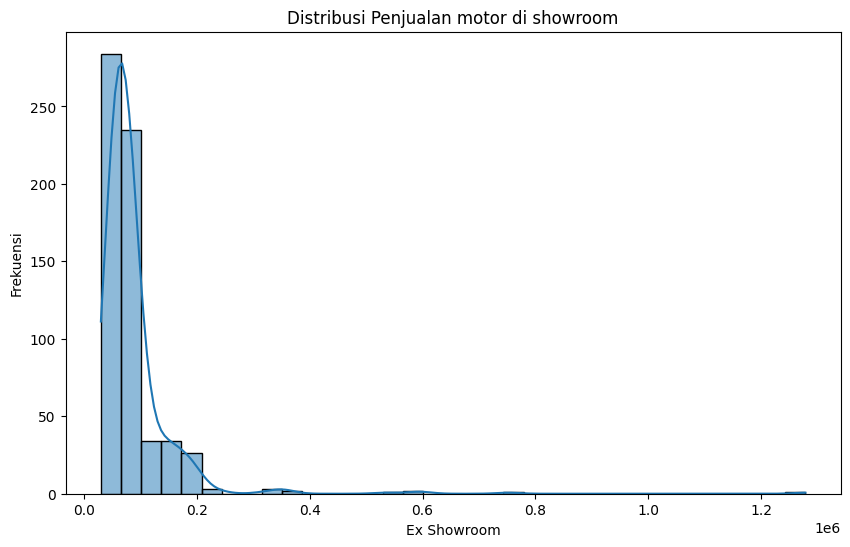

In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ex_showroom_price'], bins=35, kde=True)
plt.title('Distribusi Penjualan motor di showroom')
plt.xlabel('Ex Showroom')
plt.ylabel('Frekuensi')
plt.show()

Dalam dataset ini, pendistribusian ex showroom lebih condong kekiri, maka akan diperbaiki dengan menggunakan imputasi dengan median.

In [69]:
df['ex_showroom_price'] = df['ex_showroom_price'].fillna(df['ex_showroom_price'].dropna().median())

In [70]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
name,0.0
selling_price,0.0
year,0.0
seller_type,0.0
owner,0.0
km_driven,0.0
ex_showroom_price,0.0


seperti yang dapat dilihat tabel missing velues sudah aman dan data yang hilang telah diperbaiki, akan tetapi masih terdapat outliers didalam dataset.

### **Outliers**

Pada bagian ini saya akan memperbaiki dua kolom yaitu pada bagian ex showroom, selling price, dan km driven. Alasannya karena untuk membuat harga ex showroom dan selling price lebih sesuai agar tidak terjadinya kesalahan perbandingan, dan untuk bagian km driven diperbaiki karena terdapat beberapa data yang memili jarak tempuh yang tidak normal.

In [71]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
selling_price,8.199811
km_driven,3.675778
ex_showroom_price,11.310085


In [72]:
columns_to_impute = ["ex_showroom_price", "ex_showroom_price"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [73]:
columns_to_impute = ["km_driven", "km_driven"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [74]:
columns_to_impute = ["selling_price", "selling_price"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [75]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
selling_price,0.0
km_driven,0.0
ex_showroom_price,0.0


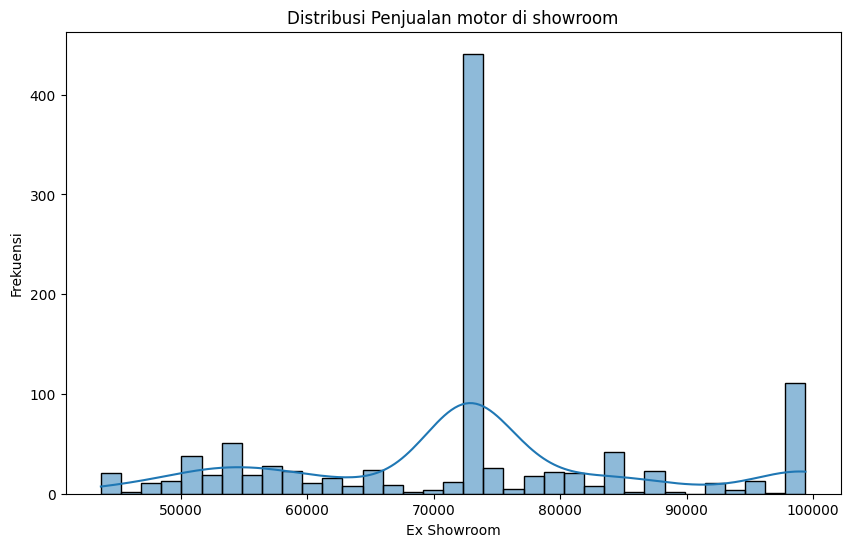

In [76]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ex_showroom_price'], bins=35, kde=True)
plt.title('Distribusi Penjualan motor di showroom')
plt.xlabel('Ex Showroom')
plt.ylabel('Frekuensi')
plt.show()

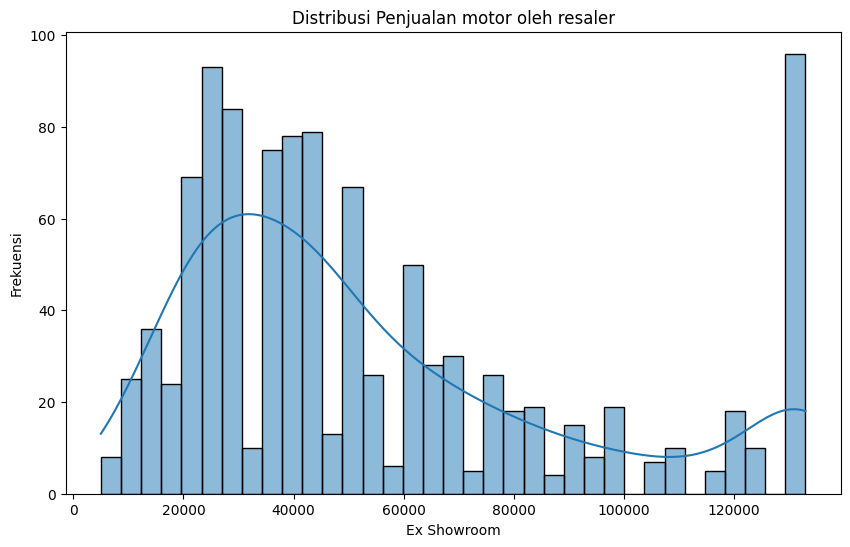

In [77]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=35, kde=True)
plt.title('Distribusi Penjualan motor oleh resaler')
plt.xlabel('Ex Showroom')
plt.ylabel('Frekuensi')
plt.show()

Dapat dilihat data pada bagian selling price, km driven, dan ex showroom sudah tidak ada outliers, sementara pada bagian year tidak saya lakukan perbaikan karena saya rasa pada bagian year itu memang wajar jika ada motor yang di produksi pada tahun yang sanggat lama.

### **Duplicate Velues**

In [78]:
df[df.duplicated()]

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
231,TVS APACHE RTR 200 4V,95000.0,2018-01-01,Individual,1st owner,9600,72752.5
328,ROYAL ENFIELD CLASSIC 350,133000.0,2018-01-01,Individual,1st owner,17365,72752.5
508,BAJAJ PULSAR 135 LS,20000.0,2010-01-01,Individual,1st owner,80000,64589.0
522,BAJAJ PLATINA 100,20000.0,2012-01-01,Individual,1st owner,16295,72752.5
605,HERO KARIZMA [2003-2014],50000.0,2013-01-01,Individual,1st owner,38000,85766.0
607,HONDA CB HORNET 160R,70000.0,2017-01-01,Individual,1st owner,35000,87719.0
773,HONDA ACTIVA [2000-2015],23000.0,2009-01-01,Individual,1st owner,87250,50267.0


Pada bagian duplicate velues, terdapat 7 data yang memiliki duplikasi data. pada bagian ini tidak akan saya perbaiki karena menurut saya data yang ter duplikasi itu merupakan data yang normal karena bisa saja ada motor yang dijual pada tahun ataupun jenis yang sama.

### **Construct Data**

Pada bagian ini saya menambahkan kolom baru pada dataset saya, kolom berupa klasifikasi harga motor mewah (high), normal (medium), atau biasa (low)

In [79]:
def VARIABEL(selling_price):
    if selling_price > 50000:
        return 'Mewah (high)'
    elif selling_price < 20000:
        return 'Biasa (low)'
    else:
        return 'Normal (medium)'

df['price_category'] = df['selling_price'].apply(VARIABEL)

In [80]:
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,price_category
0,ROYAL ENFIELD CLASSIC 350,133000.0,2019-01-01,Individual,1st owner,350,72752.5,Mewah (high)
1,HONDA DIO,45000.0,2017-01-01,Individual,1st owner,5650,72752.5,Normal (medium)
2,ROYAL ENFIELD CLASSIC GUNMETAL GREY,133000.0,2018-01-01,Individual,1st owner,12000,99399.0,Mewah (high)
3,YAMAHA FAZER FI V 2.0 [2016-2018],65000.0,2015-01-01,Individual,1st owner,23000,89643.0,Mewah (high)
4,YAMAHA SZ [2013-2014],20000.0,2011-01-01,Individual,2nd owner,21000,72752.5,Normal (medium)


Seperti yang dapat dilihat data baru pada bagian price category telah ditambahkan untuk mengecek apakah harga dari motor yang dijual apakah termasuk kategori mewah, normal, atau biasa.

### **Data Reduction**

Pada bagian ini saya akan menghapus dataset pada kolom seller type, hal ini saya lakukan karena saya rasa seller type akan kurang berdampak penting saat menwarkan penjualan motor kepada konsumen. Karena pada dataset ini yang di perhatikan adalah perbandingan harga penjualan sekarang dengan harga ex showroom lama.

In [81]:
df = df.drop('seller_type', axis=1)

In [82]:
df.head()

,name,selling_price,year,owner,km_driven,ex_showroom_price,price_category
0,ROYAL ENFIELD CLASSIC 350,133000.0,2019-01-01,1st owner,350,72752.5,Mewah (high)
1,HONDA DIO,45000.0,2017-01-01,1st owner,5650,72752.5,Normal (medium)
2,ROYAL ENFIELD CLASSIC GUNMETAL GREY,133000.0,2018-01-01,1st owner,12000,99399.0,Mewah (high)
3,YAMAHA FAZER FI V 2.0 [2016-2018],65000.0,2015-01-01,1st owner,23000,89643.0,Mewah (high)
4,YAMAHA SZ [2013-2014],20000.0,2011-01-01,2nd owner,21000,72752.5,Normal (medium)


# **Visualisasi Data**

Setelah melanjutkan perbaikan data, selanjutnya disini saya akan mencoba untuk membuat visualisasi data

terdapat 8 visualisasi yang akan saya tampilkan yaitu:

Bar Chart

Pie Chart

Line Chart

Histogram

BoxPlot

ScatterPlot

Bubble Chart

Heatmap

## **Bar Chart**

Pada bagian ini saya akan membuat bar chart untuk perbandingan kategori harga motor yang dijual kembali termasuk kedalam kategori mewah, normal ataupun biasa

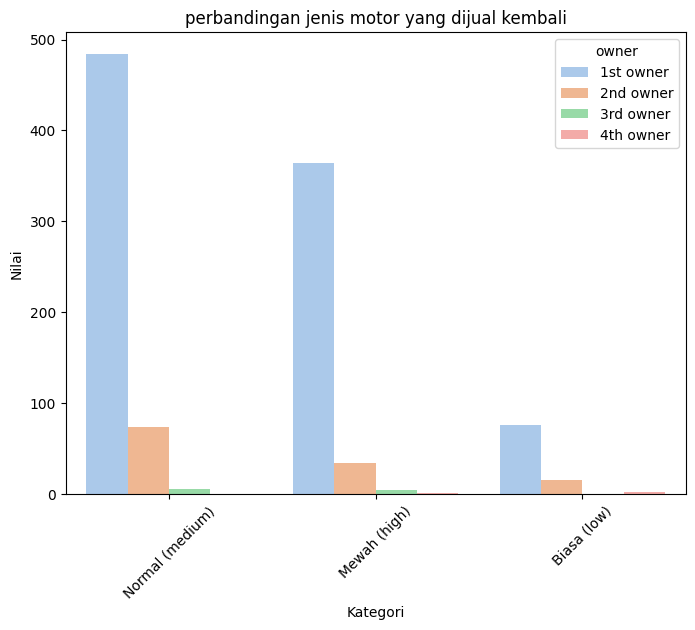

In [83]:
# Bar Chart (Seaborn)
top5negara = df['price_category'].value_counts().sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan
df_filtered = df[df['price_category'].isin(top5negara.index)]

plt.figure(figsize=(8, 6)) # Ukuran
sns.countplot(x='price_category', data=df_filtered, hue="owner", palette='pastel', order=top5negara.index) # palette (warna)
plt.title('perbandingan jenis motor yang dijual kembali') # Judul
plt.xlabel('Kategori') # Keterangan X
plt.ylabel('Nilai') # Keterangan Y
plt.xticks(rotation=45)
plt.show()

Dapat dilihat pada gambar bar chart diatas bahwa kategori Mewah dan Normal paling banyak dijual kembali, terutama oleh pemilik pertama. Hal ini menunjukkan bahwa motor di segmen menengah dan premium lebih likuid di pasar, sehingga pembeli memiliki banyak pilihan dan penjual lebih mudah melepas asetnya. Sebaliknya, motor kategori Biasa jarang dijual kembali, menandakan permintaan lebih rendah atau motor tersebut lebih lama dipakai sebelum dijual.

Solusi yang dapat diberikan ialah fokuskan strategi penjualan pada motor kategori Mewah dan Normal dengan menonjolkan status 1st owner sebagai nilai tambah. Untuk kategori Biasa, gunakan pendekatan harga ekonomis atau paket promosi agar tetap menarik bagi segmen pembeli yang sensitif harga. Dengan begitu, dealer dapat memaksimalkan keuntungan dari segmen premium sekaligus menjaga perputaran stok di segmen menengah dan rendah.


## **Pie Chart**

Selanjutnya disini saya akan membuat visualisasi dari pie chart untuk melihat perbandingan motor berdasarkan owner yang ingin menjualnya

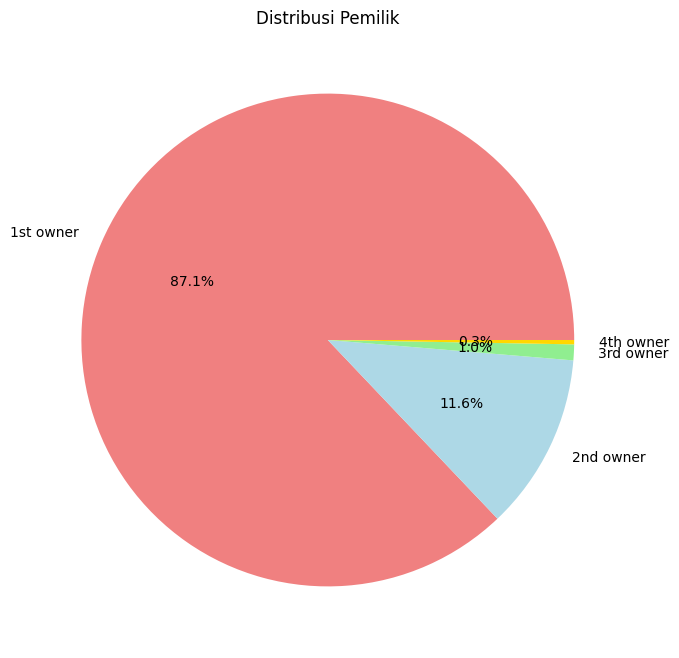

In [84]:
# Pie Chart (Matplotlib) (HANYA 1 KOLOM)
plt.figure(figsize=(8, 8)) # ukuran
plt.pie(df['owner'].value_counts(), labels=df['owner'].value_counts().index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'lightgreen', 'gold']) # colors (warna)
plt.title('Distribusi Pemilik') # Judul
plt.show()

Dapat dilihat dari visualisasi diatas bahwa kebanyakan mayoritas motor yang dijual kembali masih berasal dari pemilik pertama, sementara motor dengan pemilik kedua ke atas jumlahnya jauh lebih sedikit. Hal ini menandakan bahwa motor dari pemilik pertama lebih terjaga kualitasnya dan lebih diminati pasar karena riwayat penggunaan lebih jelas. Motor dengan kepemilikan kedua atau lebih biasanya kurang menarik bagi pembeli karena dianggap berisiko lebih tinggi terhadap kerusakan atau perawatan yang tidak konsisten.

Solusi yang disarankan adalah dengan memprioritaskan promosi dan penawaran khusus untuk motor dengan status 1st owner sebagai nilai jual utama. Untuk motor dengan pemilik kedua ke atas, dapat berikan transparansi kondisi riwayat servis, garansi tambahan, atau inspeksi teknis agar tetap bisa menarik minat pembeli yang mencari harga lebih terjangkau. Dengan strategi ini, kepercayaan konsumen diharapkan meningkat dan peluang penjualan lebih optimal.


## **Line Chart**

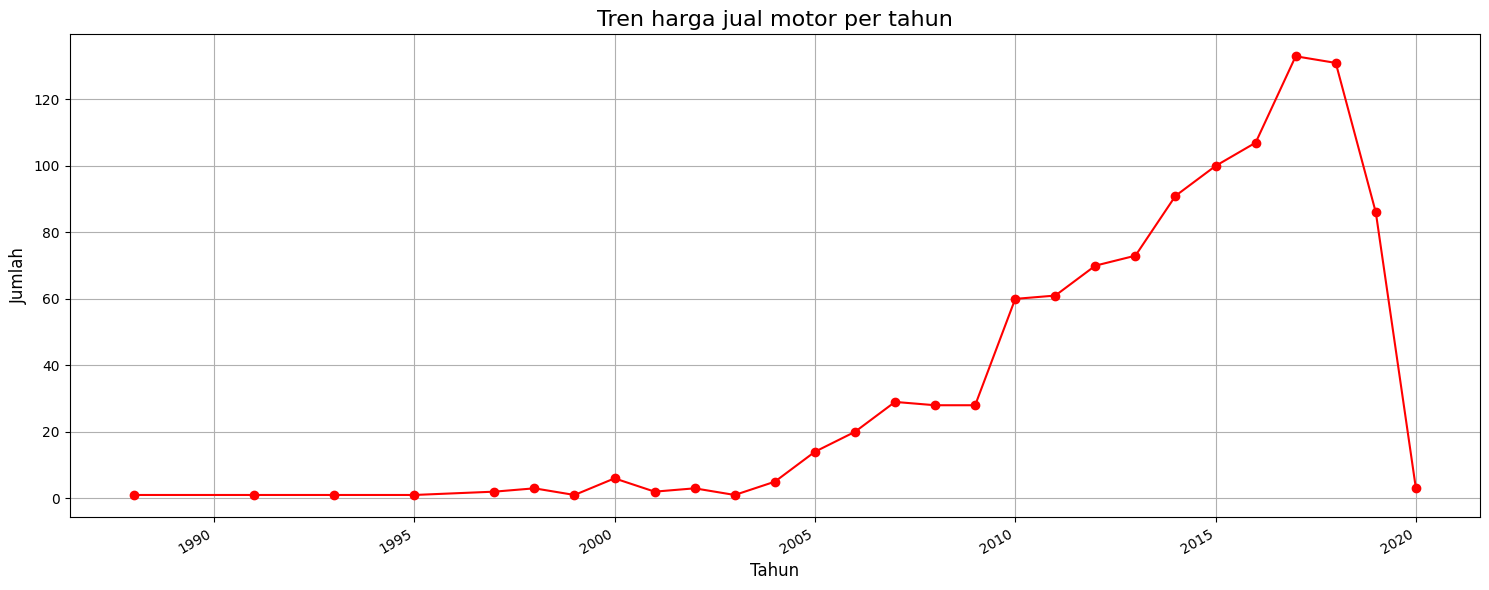

In [85]:
# Line Chart (Matplotlib) Berdasarkan Tahun

# Pastikan kolom bertipe datetime
df['year'] = pd.to_datetime(df['year'])

# Group by year
harga = df.groupby(df['year'].dt.year).size()

plt.figure(figsize=(15, 6)) # Ukuran
plt.plot(harga.index, harga.values, marker='o', color='red') # Color = Warna
plt.title('Tren harga jual motor per tahun', fontsize=16) # Judul
plt.xlabel('Tahun', fontsize=12) # X Keterangan
plt.ylabel('Jumlah', fontsize=12) # Y Keterangan'
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Dapat dilihat pada line chart diatas terdapat informasi terkait harga penjualan motor yang ada didalam dataset, dapat di lihat bahwa penjualan motor di tahun 2000an keatas memiliki jumlah yang sangat banyak itu artinya motor keluaran terbaru banyak sekali peminatnya dari pada motor keluaran lama. Dengan demikian disarankan untuk kalian yang ingin membeli atau menjual motornya dapat dilakukan dari sekarang karena dilihat tren dalam kurun waktu beberapa tahun terakhir sangat banyak peminatnya.

## **Histogram**

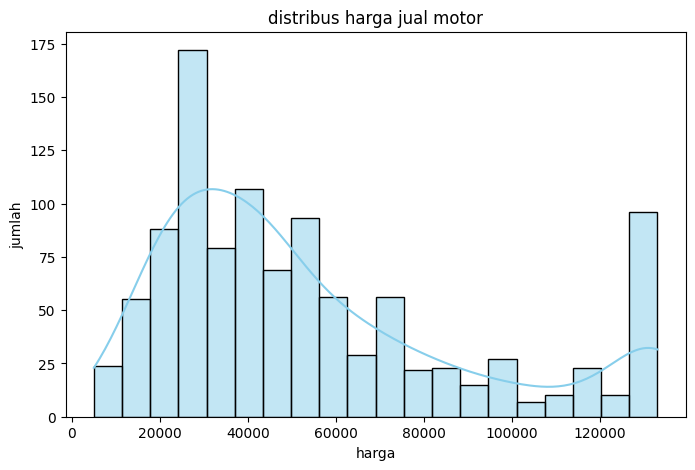

In [86]:
plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], bins=20, kde=True, color='skyblue')
plt.title('distribus harga jual motor')
plt.xlabel('harga')
plt.ylabel('jumlah')
plt.show()

*Sebelumnya saya jelaskan dulu kenapa harga motornya ada yang 20 ribu itu karena dataset ini merupakan dataset penjualan motor diseluruh dunia oleh karena itu untuk mempermudah penjelasan maka anggap saja satuan dari harga motor ini adalah USD*

Tren harga jual motor menunjukkan peningkatan signifikan sejak pertengahan 2000-an hingga mencapai puncak sekitar 2018, lalu menurun tajam setelahnya. Hal ini menandakan bahwa motor keluaran baru lebih diminati dibanding motor lama, namun minat pasar mulai jenuh atau bergeser setelah 2018.

Solusi yang dapat diberikan adalah memberikan strategi harga kompetitif untuk motor keluaran setelah 2018 agar tetap menarik. Bagi pembeli.

## **BloxPlot**

Selanjutnya ada bloxplot, disini saya akan melihat pesebaran km_driven berdasarkan dari price_category, hal ini dilakukan untuk mengecek apakah jarak tempuh penggunaan motor berpengaruh dengan kategori harga jual motor.

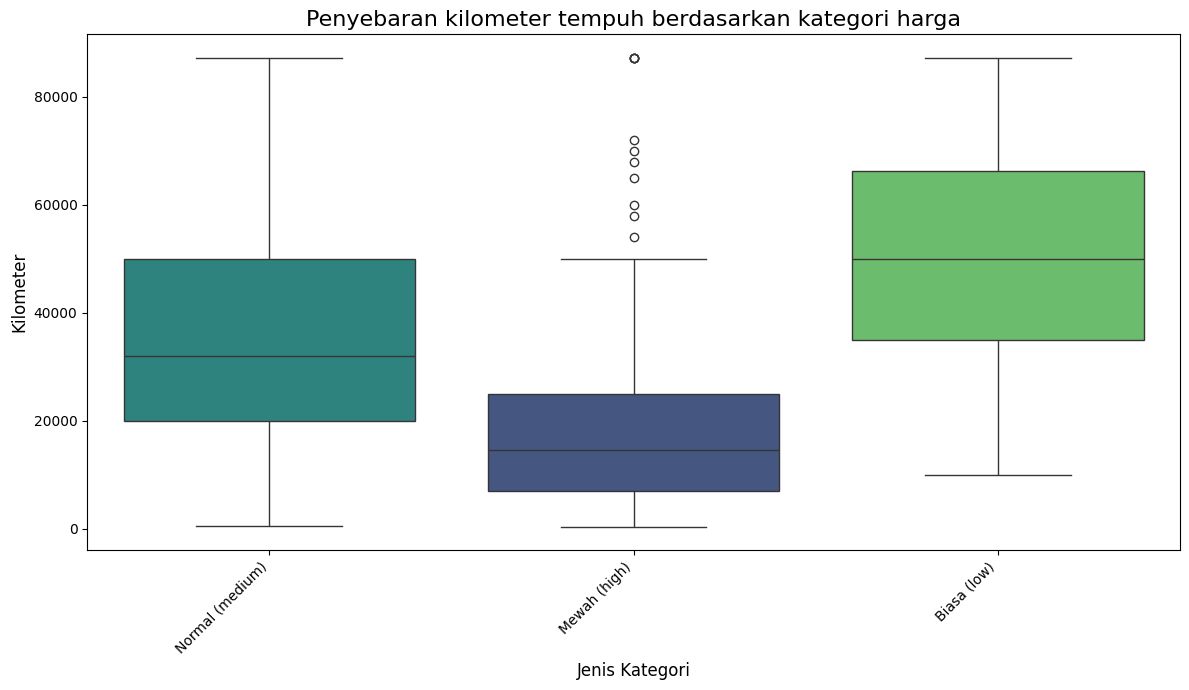

In [87]:
category = df['price_category'].value_counts().head(5).index
kilometer = df[df['price_category'].isin(category)]

plt.figure(figsize=(12, 7)) # Ukuran figure
sns.boxplot(x='price_category', y='km_driven', data=kilometer, palette='viridis', order=category, hue='price_category', legend=False)
plt.title('Penyebaran kilometer tempuh berdasarkan kategori harga', fontsize=16) # Judul
plt.xlabel('Jenis Kategori', fontsize=12) # X Keterangan
plt.ylabel('Kilometer', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dapat dilihat bahwa motor dengan kategori Mewah cenderung memiliki kilometer tempuh lebih rendah, menandakan kondisi lebih terawat dan layak dijual dengan harga premium. Sebaliknya, kategori Biasa menunjukkan kilometer tinggi, sehingga nilai penjualannya lebih rendah dan lebih cocok dipasarkan ke segmen pembeli yang mencari motor murah untuk kebutuhan harian. Kategori Normal berada di tengah dengan variasi cukup lebar, sehingga strategi harga harus fleksibel sesuai kondisi motor.

Solusi yang diberikan adalah untuk fokus pada promosian motor kategori Mewah dengan menekankan keunggulan kilometer rendah, gunakan kategori Normal sebagai opsi menengah dengan penawaran diskon atau paket menarik, dan posisikan kategori Biasa sebagai pilihan ekonomis untuk pasar yang sensitif harga. Dengan segmentasi ini, penjualan bisa lebih terarah sesuai target pembeli.

## **ScatterPlot**

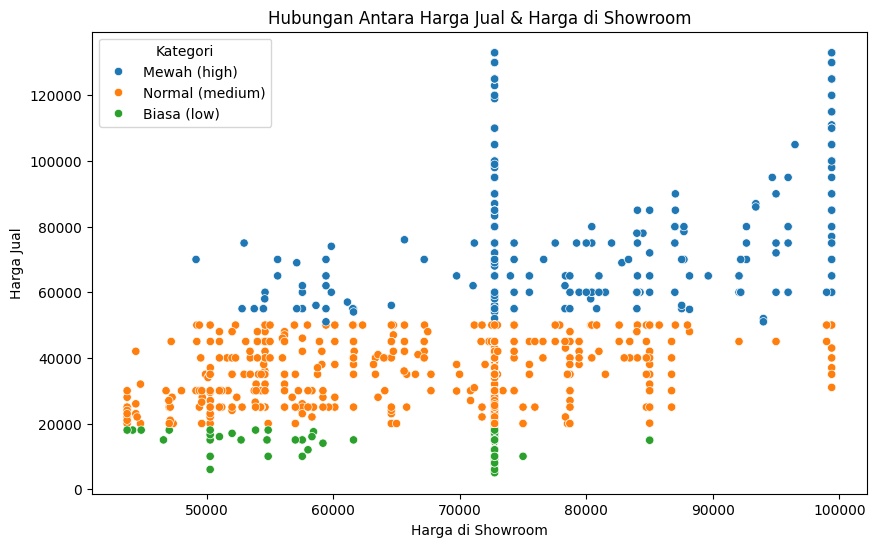

In [88]:
# Scatter Plot (Seaborn)
plt.figure(figsize=(10, 6)) # Ukuran
sns.scatterplot(x='ex_showroom_price', y='selling_price', hue='price_category', data=df)
plt.title('Hubungan Antara Harga Jual & Harga di Showroom') # Judul
plt.xlabel('Harga di Showroom') # X Keterangan
plt.ylabel('Harga Jual') # Y Keterangan
plt.legend(title='Kategori') # Keterangan dalam kotak kecil
plt.show()

Dari scatter plot diatas terlihat bahwa motor kategori Mewah memiliki harga jual yang relatif dekat dengan harga showroom, menandakan nilai jualnya lebih terjaga. Motor kategori Normal cenderung berada di tengah, dengan harga jual lebih rendah dari showroom namun masih stabil. Sedangkan kategori Biasa mengalami penurunan harga yang cukup tajam dibandingkan harga showroom, menunjukkan depresiasi lebih besar. Motor dengan kategori premium lebih tahan terhadap penurunan harga, motor normal masih cukup stabil, sementara motor kategori biasa cepat kehilangan nilai jual.

Solusi yang bisa diberikan adalah kategori Mewah cocok dijadikan investasi karena nilai jual kembali tinggi. Kategori Normal bisa jadi pilihan seimbang antara harga terjangkau dan nilai jual yang masih baik. Kategori Biasa lebih cocok untuk penggunaan jangka panjang dengan biaya awal rendah, bukan untuk dijual kembali. Dengan memahami pola ini, diharapkan pembeli bisa menyesuaikan pilihan sesuai kebutuhan dan strategi finansial.


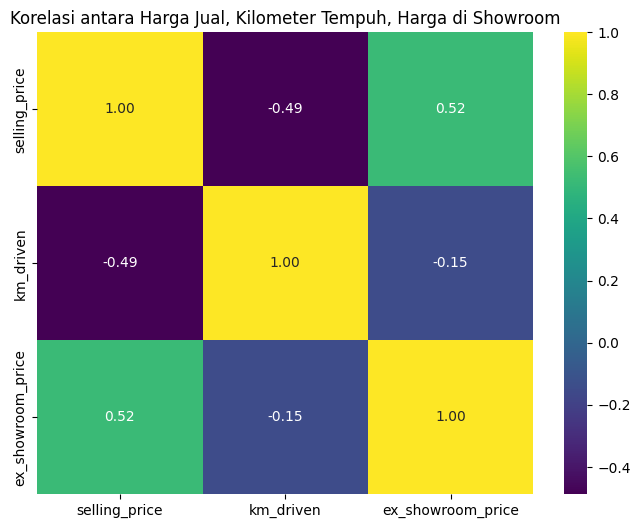

In [89]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df.corr(numeric_only=True),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Harga Jual, Kilometer Tempuh, Harga di Showroom')
plt.show()

Dari heatmap diatas dapat dilihat bahwa harga jual memiliki korelasi positif sedang dengan harga showroom (0.52), artinya semakin tinggi harga showroom, semakin tinggi pula harga jual motor bekas. Sebaliknya, korelasi antara kilometer tempuh dan harga jual bernilai negatif (-0.49), menunjukkan bahwa semakin banyak motor dipakai, harga jualnya cenderung turun. Korelasi antara kilometer dengan harga showroom relatif lemah (-0.15), sehingga showroom price lebih dipengaruhi oleh faktor lain selain pemakaian. Sehingga motor dengan kilometer rendah lebih mudah dijual dengan harga tinggi, dan showroom price bisa dijadikan acuan untuk menentukan harga jual motor bekas.

Solusi yang bisa diberikan kepada owner yang ingin menjual kembali motor sebaiknya menekankan kondisi kilometer rendah sebagai nilai tambah dalam promosi. Pembeli bisa menggunakan showroom price sebagai patokan untuk menilai apakah harga jual bekas wajar. Dengan strategi ini, transaksi lebih transparan dan kedua pihak bisa mendapatkan nilai yang optimal.

## **Menyimpan Dataset**

In [90]:
df.to_excel('[Bersih]DETAILS.xlsx', index=False)